In [1]:
# NOTE: Neccesary on windows for sklearn.cluster.KMeans
import os
os.environ["OMP_NUM_THREADS"] = "2"

In [2]:
import cv2
import torch
import numpy as np
from segment_anything import SamAutomaticMaskGenerator, SamPredictor, sam_model_registry

from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pdr
from marslab.bandset.mastcamz import ZcamBandSet, ls_zcam
from marslab.imgops.masking import skymask, threshold_mask
from marslab.imgops.imgutils import enhance_color

from roi_classifier import (
    add_rois,
    apply_homography,
    apply_kmeans_to_masked,
    average_spectra,
    compute_homography,
    filter_connected_components,
    load_data,
    LoadResult,
    mask_cube,
    plot_spectra,
    SHARED_BANDS,
    cluster_region,
    get_center_of_mass,
    get_roi, 
    compress_cube,
    uncompress
)
from pdr.pds4_tools.extern.zscale import zscale

from sklearn.cluster import KMeans
from kneed import KneeLocator
from roi_classifier import uncompress
from joblib import parallel_backend

from scipy.ndimage import binary_opening, binary_fill_holes, center_of_mass, find_objects, label, distance_transform_edt

In [3]:
# pipeline settings

CLUSTER_KWARGS = {
    'edge_offset': 10,
    'allowed_variance': 1
}
ROI_AREA_THRESHOLD = 50
THRESHOLD_KWARGS = {
    'percentiles': (6, 99),
    'operator': 'and'
}
SKYMASK_KWARGS = {
    'percentile': 75,
    'edge_params': {"maximum": 5, "erosion": 3},
    'input_median': 5,
    'trace_maximum': 5,
    'cutoffs': {
        "extent": 0.05, "coverage": None, "v": 0.9, "h": None
    },
    'input_mask_dilation': None,
    'input_stretch': (10, 1),
    'floodfill': True,
    'trim_params': {"trim": False},
    'clear': True,
    'colorblock': False,
    'respect_mask': False,
}

### Load, Pre-process cube

In [4]:
# NOTE: get_zcam_bandset expects a directory structure like:
# sol
# sol/iof
# sol/pix_map

# SEARCH_PATH = Path("data/new/1164/3")
SEARCH_PATH = Path("e:/products/0012/iof")
SEQ_ID, OBS_IX = None, 0  # changed from 2
# NOTE: load_data crops the images inline; trim_margins() is no longer needed
load_result: LoadResult = load_data(
    SEARCH_PATH, seq_id=SEQ_ID, obs_ix=OBS_IX, do_apply_pixmaps=True  # changed to False
)

In [5]:
l_cube, r_cube = load_result["l_cube"], load_result["r_cube"]

In [6]:
# b/c we might have applied NaN values to bands of the cube, always use
# the original bands for computing homography (NaNs make cv2's SIFT
# implementation unhappy)

base_bands = load_result["base_bands"]
h_matrix = compute_homography(
    base_bands[SHARED_BANDS["L"]], base_bands[SHARED_BANDS["R"]],
)
l_cube_mapped = apply_homography(l_cube, h_matrix, r_cube[0].shape)

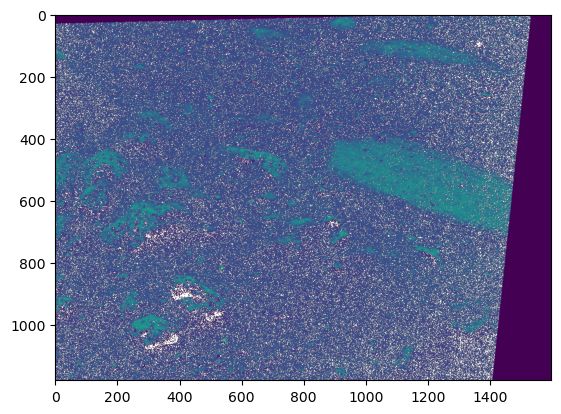

In [7]:
plt.imshow(l_cube_mapped[0])

In [8]:
full_cube = []
shared_band_index = (
    sorted(load_result["bandset"].raw)
     .index(SHARED_BANDS['L'])
)
# average left/right views of Bayer and 800nm bands
for band in range(shared_band_index + 1):
    img = (l_cube_mapped[band] + r_cube[band]) / 2
    full_cube.append(img)

# add left bands
l_num_bands = l_cube.shape[0]
for band in range(shared_band_index + 1, l_num_bands):
    full_cube.append(l_cube_mapped[band])

# add right bands
r_num_bands = r_cube.shape[0]
for band in range(shared_band_index + 1, r_num_bands):
    full_cube.append(r_cube[band])

full_cube = np.array(full_cube)

### Masking shaddows and sky

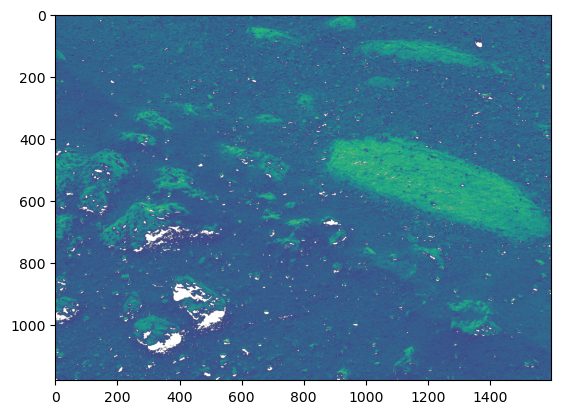

In [9]:
THRESHOLD_KWARGS = {
    'percentiles': (4, 99),
    'operator': 'and'
}
r_cube_base = np.array(
    [a for b, a in base_bands.items() if b.startswith('R')]
)
shadow_tmask = threshold_mask(r_cube_base, **THRESHOLD_KWARGS)

img = np.ma.masked_array(r_cube_base[3], mask=shadow_tmask)
plt.imshow(img)
plt.show()

In [10]:
# NOTE: this is an unnecessary copy if we didn't apply pixmaps
r_cube_base = np.array(
    [a for b, a in base_bands.items() if b.startswith('R')]
)
# mask shadows
shadow_tmask = threshold_mask(r_cube_base, **THRESHOLD_KWARGS)

# mask the sky
sky_tmask = skymask(r_cube_base, **SKYMASK_KWARGS)

del r_cube_base

In [11]:
# mask the overlap bewteen the cameras
overlap_mask = (l_cube_mapped[shared_band_index] == 0)

# combine the masks into one
feature_mask = np.logical_or(shadow_tmask, sky_tmask)
full_tmask = np.logical_or(feature_mask, overlap_mask)

In [12]:
cube_preprocessed = mask_cube(full_cube, full_tmask)

cube_preprocessed.mask = (
    cube_preprocessed.mask | ~np.isfinite(cube_preprocessed)
)

### Split scene into segments

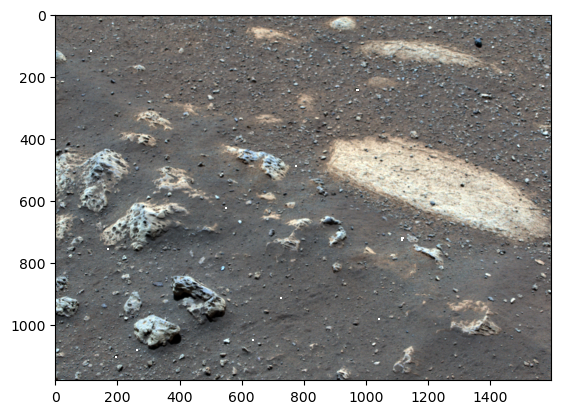

In [13]:
# creates rgb image from right bayer bands
red = r_cube[2]
green = r_cube[1]
blue = r_cube[0]

rgb = np.ma.masked_invalid(np.stack([red, green, blue], axis=-1))
rgb_normalized = enhance_color(rgb, (0, 1), 0.1)

plt.imshow(rgb_normalized)
plt.show()

In [14]:
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"

sam = sam_model_registry[MODEL_TYPE](checkpoint="C:\\Users\\Lars\\Documents\\Python\\mars_lab\\models\\sam_vit_h_4b8939.pth")
sam.to(device=DEVICE)

predictor = SamPredictor(sam)
mask_generator = SamAutomaticMaskGenerator(sam)

output_mask = mask_generator.generate(rgb_normalized)

In [15]:
# sort segments based on pixel area
sorted_result = sorted(output_mask, key=(lambda x: x["area"]), reverse=True)

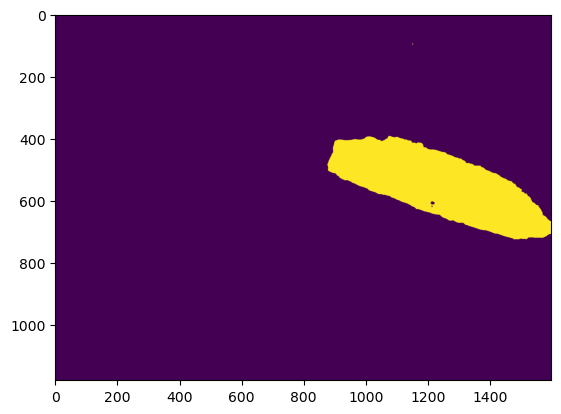

In [16]:
# visualize largest segment
plt.imshow(sorted_result[0]["segmentation"])

count=126


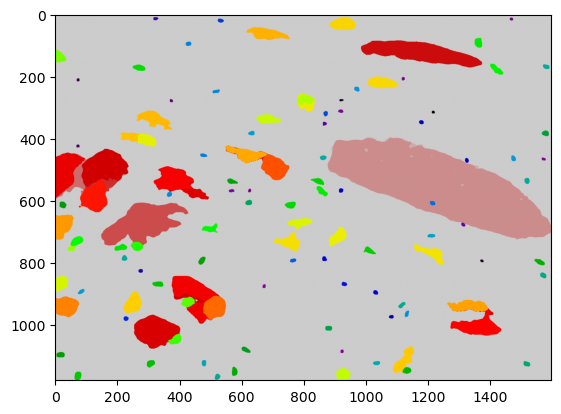

In [17]:
# create mask with unique label for each segment

dim = rgb_normalized.shape[:2]
classified_regions_mask = np.zeros(dim)

# populate mask
region_count = 0
for val in sorted_result:

    mask = val["segmentation"]
    classified_regions_mask[mask] = region_count

    region_count += 1

print(f"count={region_count}")

ax = plt.gca()
fig = ax.get_figure()

ax.imshow(classified_regions_mask, cmap="nipy_spectral_r")

### Classify ROI in each segment

In [18]:
# TODO: try cluster stepping, shaddow mask with elbow approach

In [19]:
# compress cube
original_cube_shape = cube_preprocessed.shape
compressed_cube, pixel_mapping = compress_cube(cube_preprocessed)

In [20]:
rois = []

# loop physical SAM regions
for region_i in range(len(sorted_result)):

    # spectrally cluster
    region = [classified_regions_mask == region_i]
    cluster_ret = cluster_region(region, full_tmask, cube_preprocessed, **CLUSTER_KWARGS)

    if cluster_ret == None:
        continue

    # print(f'running with {region_i}')

    clusters, k = cluster_ret

    # identify roi for each cluster
    for cluster in range(k):

        slice = (clusters.data == cluster) & ~clusters.mask
        area, roi = get_roi(slice)

        rois.append(roi)

In [21]:
valid_rois = np.where([roi[2] * roi[3] >= ROI_AREA_THRESHOLD for roi in rois])[0]
area_constrained_rois = np.array([rois[i] for i in valid_rois])

In [22]:
# filter rois based on spectral error and similarity

DO_APPLY_R_STAR = True

# NOTE: using Data.metaget() here can be sketchy
#  b/c ZCAM metadata has multiple solar elevation values
#  in different coordinate systems, not always in the same
#  order in different label versions!
if DO_APPLY_R_STAR is True:
    meta = load_result["bandset"].metadata
    incidence = meta["INCIDENCE_ANGLE"].unique().mean()
    photometric_scaling = np.cos(incidence * 2 * np.pi / 360)
else:
    photometric_scaling = 1

if DO_APPLY_R_STAR is False:
    y_axis_units = "IOF"
else:
    y_axis_units = "Relative Reflectance"

# scale the cube
photometrically_calibrated = cube_preprocessed / photometric_scaling

In [23]:
# convert rect coords to plot coords
plt_rois = []
for i in range(len(area_constrained_rois)):
    x1, y1, w, h = area_constrained_rois[i]
    x2 = x1 + w
    y2 = y1 + h
    plt_rois.append((x1, y1, x2, y2))

# calculate average spectra in roi regions
spectra, stds = average_spectra(photometrically_calibrated, plt_rois)

### Testing begins here... hold onto your butts

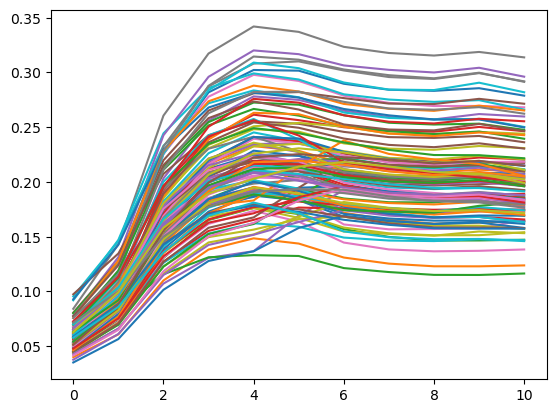

In [24]:
WLS = [630, 544, 480, 800, 754, 677, 605, 528, 442, 866, 910, 939, 978, 1022]

bayer_sorted_indices = np.argsort(WLS[:3])
non_bayer_sorted_indices = np.argsort(WLS[3:]) + 3

non_bayer_spectra = spectra[:, non_bayer_sorted_indices]

plt.plot(non_bayer_spectra.T)
plt.show()

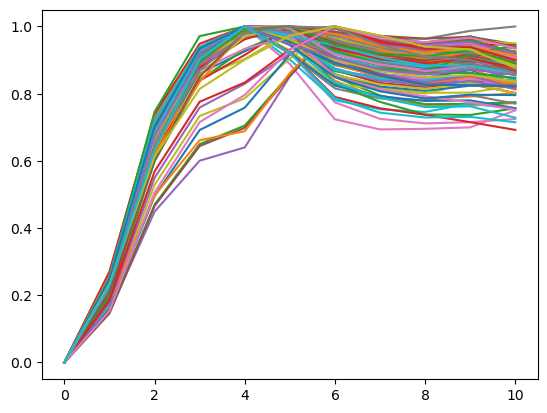

In [25]:
roi_spectra_norm = []

for s in non_bayer_spectra:
    spectra_norm = s.copy()
    
    min = spectra_norm.min()
    spectra_norm -= min

    max = spectra_norm.max()
    spectra_norm /= max
    
    roi_spectra_norm.append(spectra_norm)

roi_spectra_norm = np.array(roi_spectra_norm)

plt.plot(roi_spectra_norm.T)
plt.show()

In [26]:
def auto_k_elbow(X, k_range=range(5, 20)):
    inertias = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)
    kl = KneeLocator(k_range, inertias, curve="convex", direction="decreasing")
    return kl.knee if kl.knee else k_range[np.argmin(np.gradient(inertias))]

In [27]:
# inertias = []
# k_range = range(1, 20)
# X = roi_spectra_norm
# for k in k_range:
#     kmeans = KMeans(n_clusters=k, n_init='auto')
#     kmeans.fit(X)
#     inertias.append(kmeans.inertia_)
# kl = KneeLocator(k_range, inertias, curve="convex", direction="decreasing")
# # return kl.knee if kl.knee else k_range[np.argmin(np.gradient(inertias))]

# n_clusters = kl.knee
# print(n_clusters)

# plt.plot(inertias)
# plt.show()

In [28]:
n_clusters = auto_k_elbow(roi_spectra_norm)
print(n_clusters)

10


c:\Users\Lars\anaconda3\envs\marslab\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Lars\anaconda3\envs\marslab\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Lars\anaconda3\envs\marslab\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Lars\anaconda3\envs\marslab\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

In [29]:
k_means = KMeans(
    n_clusters=n_clusters, random_state=42
)  # NOTE: random state set to make deterministic
classifications = k_means.fit_predict(roi_spectra_norm)

c:\Users\Lars\anaconda3\envs\marslab\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


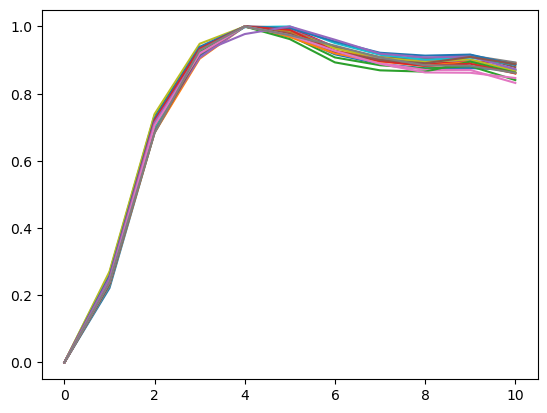

In [30]:
plt.plot(roi_spectra_norm[classifications == 0].T)
plt.show()

In [31]:
# avg_albedos = np.mean(spectra, axis=1)  # mean reflectance at each pixel
# avg_albedo = np.mean(avg_albedos)
# max_albedo_diff = np.max(avg_albedos) - np.min(avg_albedos)

# i = 12
# curr_albedo = avg_albedos[i]
# albedo_norm = curr_albedo / max_albedo_diff  # averaged albedo difference

# print((curr_albedo - avg_albedo) / (np.max(avg_albedos) - avg_albedo))

# print(albedo_norm)

In [32]:
minimized_roi_indices = []

areas = [coords[2] * coords[3] for coords in area_constrained_rois]  # pixel area of rois
max_area_diff = np.max(areas) - np.min(areas)

avg_albedos = np.mean(spectra, axis=1)  # mean reflectance at each pixel
avg_albedo = np.mean(avg_albedos)
# max_albedo_diff = np.max(avg_albedos) - np.min(avg_albedos)

avg_errs = np.mean(stds, axis=1)
max_err_diff = np.max(avg_errs) - np.min(avg_errs)

# find most representative roi for each spectral category
for category in np.unique(classifications):

    # indices of rois in current category
    indices = np.where(classifications == category)[0]

    curr_score = 0
    chosen_i = indices[0]
    for i in indices:
        curr_area = areas[i]
        area_norm = (curr_area - np.min(areas)) / max_area_diff
        
        curr_albedo = avg_albedos[i]
        # albedo_norm = (curr_albedo - avg_albedo) / (np.max(avg_albedos) - avg_albedo)  # averaged albedo difference
        albedo_norm = abs(curr_albedo - avg_albedo) / (np.max(avg_albedos) - avg_albedo)  # averaged albedo difference
        # albedo_norm = np.maximum(albedo_norm, 0)  # relu -- prioritize high albedo regions
        
        avg_err = avg_errs[i]
        error_norm = (avg_err - np.min(avg_errs)) / max_err_diff
        
        score = area_norm + albedo_norm - error_norm

        if score > curr_score:
            curr_score = score
            chosen_i = i

    minimized_roi_indices.append(chosen_i)

In [33]:
COLORS = [
        "#ebac23",
        "#D80039",
        "#008cf9",
        "#AB358A",
        "#F5029F",
        "#0E00EE",
        "#00EB39",
        "#f05a28",
        "#15E4B1",
        "#D16174",
        "#136B8C",
        "#DD6E12",
        "#834C71",
    ]

In [34]:
def plot_roi_img(img, rois):
    fig, ax = plt.subplots(figsize=(12, 9))
    fig.frameon = False
    ax.set_axis_off()

    ax.imshow(img)

    color_i = 0
    # for i, coord in enumerate(rois):
    for (x1, y1, x2, y2) in rois:
        # update color
        if color_i == len(COLORS): color_i = 0
        curr_color = COLORS[color_i]
        color_i += 1

        # add roi rectangle
        roi = patches.Rectangle(
            (x1, y1), x2, y2, edgecolor=curr_color, facecolor="none", linewidth=2
        )
        ax.add_patch(roi)

    plt.show()

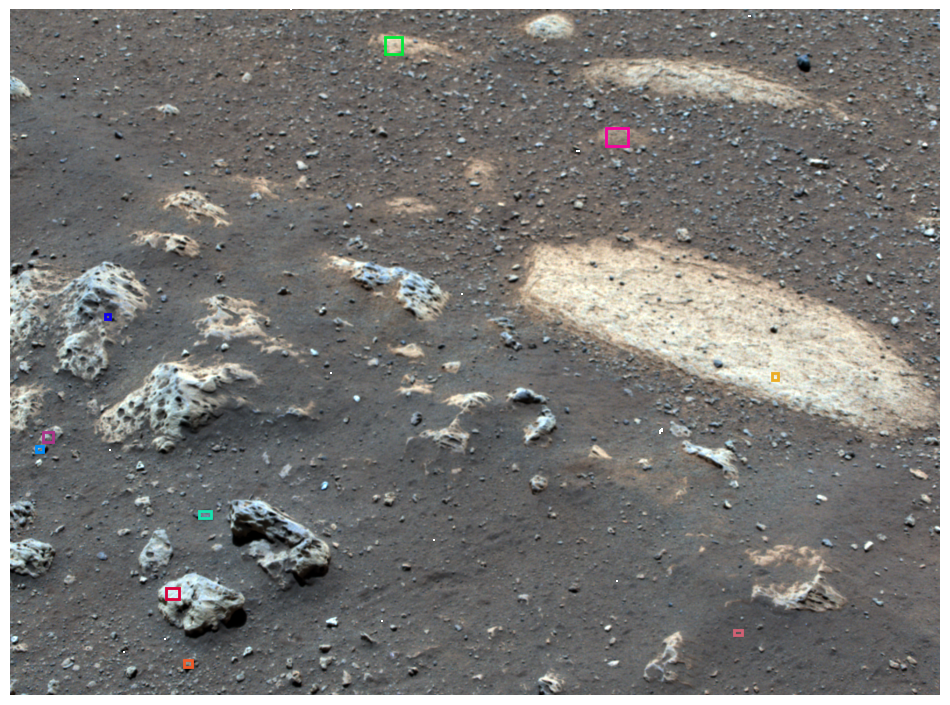

In [35]:
plot_roi_img(rgb_normalized, area_constrained_rois[minimized_roi_indices])

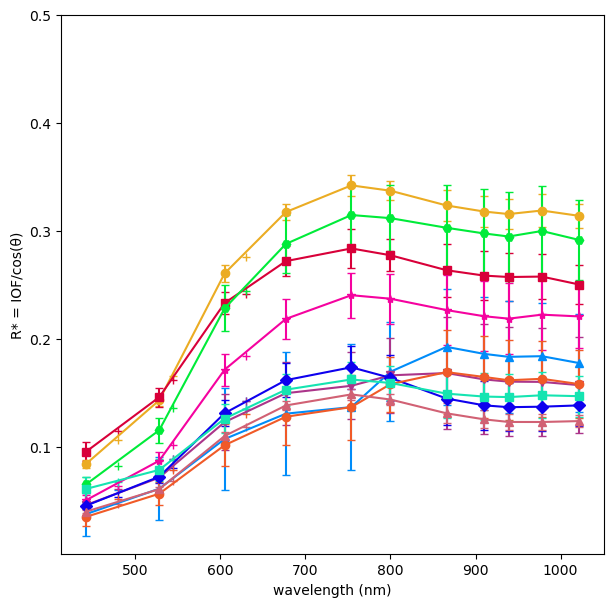

In [36]:
markers = ["o", "s", "^", "v", "*", "D", "H"]

plot_spectra(
    spectra[minimized_roi_indices], stds[minimized_roi_indices], COLORS, markers
)